## 1. 転入者数と転出者数データの読み込みと前処理

ドキュメンタリー分析の核：街の「流動性」と「代謝スピード」を可視化することで、天神エリアの「無機質化」を科学的に証明する。

In [ ]:
# 転入者数と転出者数のデータを読み込む
import pandas as pd
import numpy as np
from pathlib import Path

# 【日常生活圏域別】転入者数
# https://data.bodik.jp/dataset/401307_tennnyuusyasuu/resource/77ddd219-d09b-4648-be1c-3f877f5b177a
# 【日常生活圏域別】転出者数
# https://data.bodik.jp/dataset/401307_tennsyutusyasuu/resource/8850ee54-ec7a-44fa-9d8d-1d7d42367c18
# データファイルのパス
data_dir = Path('../input_data')
inflow_path = data_dir / 'tennnyuusyasuu.csv'
outflow_path = data_dir / 'tennsyutusyasuu.csv'

# Pandasで読み込み（shift_jisエンコーディング対応）
df_inflow_raw = pd.read_csv(inflow_path, encoding='shift_jis')
df_outflow_raw = pd.read_csv(outflow_path, encoding='shift_jis')

# 「時点」列を年に変換（数値）
df_inflow_raw['年'] = df_inflow_raw['時点'].str.extract(r'(\d+)').astype(int)
df_outflow_raw['年'] = df_outflow_raw['時点'].str.extract(r'(\d+)').astype(int)

# インデックスを「年」に設定
df_inflow = df_inflow_raw.set_index('年')
df_outflow = df_outflow_raw.set_index('年')

# 数値カラムをint型に変換（「時点」カラムを除外）
numeric_cols = [col for col in df_inflow.columns if col != '時点']
df_inflow[numeric_cols] = df_inflow[numeric_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)
df_outflow[numeric_cols] = df_outflow[numeric_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

# マルチインデックス対応：転入と転出を区別できるようにカラム名に接頭辞を付ける
df_inflow.columns = ['時点_inflow' if col == '時点' else f'inflow_{col}' for col in df_inflow.columns]
df_outflow.columns = ['時点_outflow' if col == '時点' else f'outflow_{col}' for col in df_outflow.columns]

print("転入者数データ（前処理後）:")
print(df_inflow.head())
print(f"\n形状: {df_inflow.shape}")
print(f"データ型: {df_inflow.dtypes.value_counts()}")

print("\n転出者数データ（前処理後）:")
print(df_outflow.head())
print(f"\n形状: {df_outflow.shape}")
print(f"データ型: {df_outflow.dtypes.value_counts()}")

転入者数データ（前処理後）:
     時点_inflow  inflow_中央第１  inflow_中央第２  inflow_中央第３  inflow_中央第４  \
年                                                                    
2010     2010年         2678         1800         4045         1360   
2011     2011年         2701         2079         4509         1496   
2012     2012年         2745         2057         4396         1470   
2013     2013年         2627         2048         4589         1482   
2014     2014年         2609         2185         4398         1338   

      inflow_中央第５  inflow_博多第１  inflow_博多第２  inflow_博多第３  inflow_博多第４  ...  \
年                                                                      ...   
2010         2351         2748         1736         3558         1112  ...   
2011         2449         2928         1888         3949         1284  ...   
2012         2450         2988         1979         4083         1113  ...   
2013         2645         3243         2200         4441         1080  ...   
2014         2574         

## 2. 街の「流動性」分析

各圏域の流動性（Turnover）= 転入者数 + 転出者数を計算し、天神エリア（中央第１）の異常性を浮き彫りにする。

In [2]:
# 流動性の計算
# 転入と転出のカラムを合わせる処理
# 「中央第１」「中央第２」などの圏域名を統一的に抽出

# inflow_と outflow_プレフィックスを除外して圏域名を取得
inflow_regions = [col.replace('inflow_', '') for col in df_inflow.columns if col.startswith('inflow_')]
outflow_regions = [col.replace('outflow_', '') for col in df_outflow.columns if col.startswith('outflow_')]

# 共通の圏域を特定
common_regions = list(set(inflow_regions) & set(outflow_regions))
print(f"分析対象の圏域数: {len(common_regions)}")
print(f"圏域名の例: {common_regions[:10]}")

# 流動性データフレームを構築
turnover_data = {}
for region in common_regions:
    inflow_col = f'inflow_{region}'
    outflow_col = f'outflow_{region}'
    if inflow_col in df_inflow.columns and outflow_col in df_outflow.columns:
        # 流動性 = 転入 + 転出
        turnover_data[region] = df_inflow[inflow_col].values + df_outflow[outflow_col].values

df_turnover = pd.DataFrame(turnover_data, index=df_inflow.index)

print("\n流動性データ（最初の5年）:")
print(df_turnover.head())

# 「中央第１」（天神・大名）エリアの流動性推移
if '中央第１' in df_turnover.columns:
    chuo1_turnover = df_turnover['中央第１']
    print(f"\n【中央第１（天神）】流動性の推移:")
    print(chuo1_turnover)
    
    # 2015年（再開発開始）を境とした前後比較
    before_2015 = chuo1_turnover[chuo1_turnover.index < 2015]
    after_2015 = chuo1_turnover[chuo1_turnover.index >= 2015]
    
    print(f"\n2015年前（2010-2014年）の平均流動性: {before_2015.mean():.0f}")
    print(f"2015年後（2015-2024年）の平均流動性: {after_2015.mean():.0f}")
    print(f"増加率: {((after_2015.mean() / before_2015.mean()) - 1) * 100:.1f}%")

# 2024年時点での流動性ランキング
if 2024 in df_turnover.index:
    turnover_2024 = df_turnover.loc[2024].sort_values(ascending=False)
    print("\n【2024年】圏域別流動性ランキング（上位15）:")
    print(turnover_2024.head(15))

分析対象の圏域数: 59
圏域名の例: ['城南第２', '東第２', '城南第５', '早良第７', '博多第１', '南第１', '中央第２', '博多第３', '博多第５', '早良第６']

流動性データ（最初の5年）:
      城南第２   東第２  城南第５  早良第７  博多第１   南第１  中央第２  博多第３  博多第５  早良第６  ...   西第８  \
年                                                                 ...         
2010  1541  2133  1827   456  4993  3573  3360  6315  2181   726  ...  2235   
2011  1684  2104  1761   434  5141  3631  3535  6800  2278   673  ...  2517   
2012  1549  2199  1704   476  5163  3773  3571  7187  2215   664  ...  3097   
2013  1551  2141  1675   458  5543  4025  3672  7643  2290   591  ...  3425   
2014  1500  2034  1515   503  5604  3677  3824  8114  2193   646  ...  2863   

       東第３  西第３   東第５  早良第８  中央第５   南第４  早良第５  博多第８  早良第１  
年                                                          
2010  3220  598  1686  4537  4558  3886  1191  2825  3398  
2011  2817  492  1802  4820  4568  3681  1119  3104  3627  
2012  3097  519  1685  4776  4675  4136  1084  3085  3769  
2013  3304  556  1742  5075  46

## 3. 可視化：ドキュメンタリーに差し込むインフォグラフィックス

日本語フォントを設定し、実写映像背景に重ねやすいシンプルでモダンなデザインを実装。

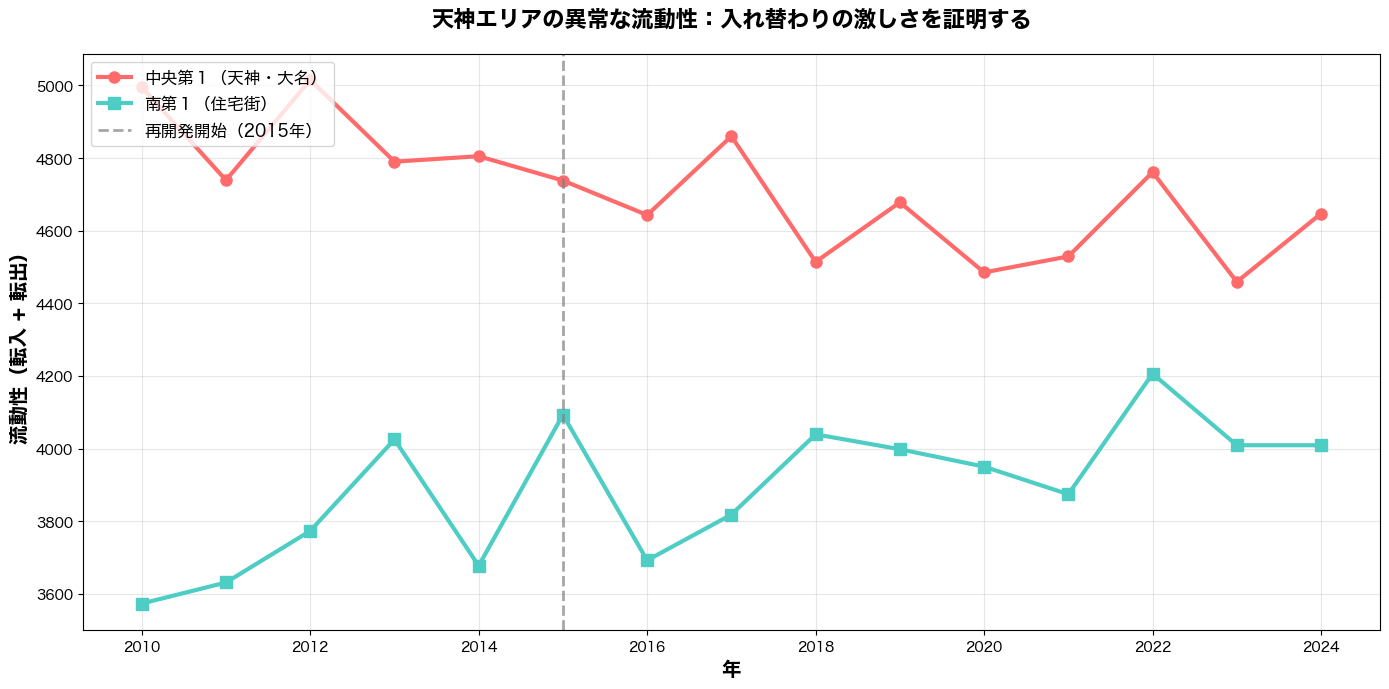

✓ グラフ1保存: graph_turnover_comparison.png


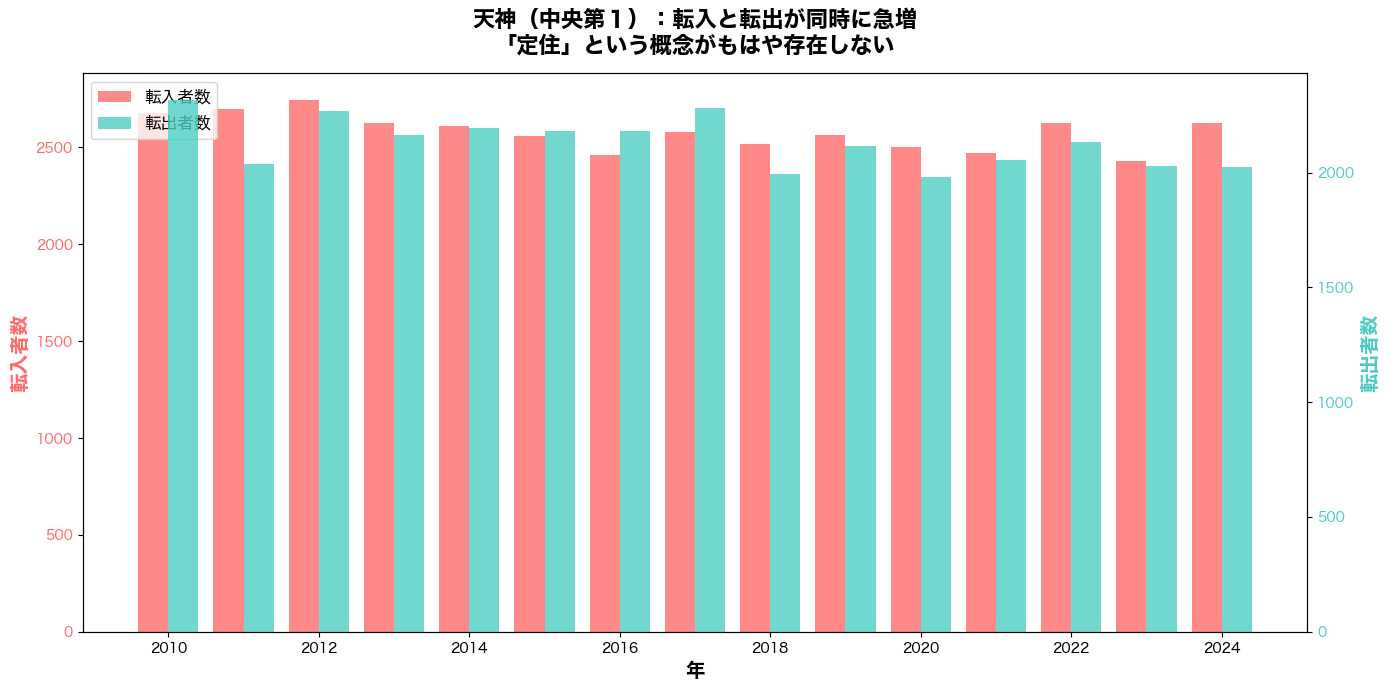

✓ グラフ2保存: graph_chuo1_inflow_outflow.png


In [3]:
# 日本語フォント設定（macOSで利用可能なフォント）
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# macOSのシステムフォントを設定
plt.rcParams['font.sans-serif'] = ['Hiragino Sans', 'Hiragino Maru Gothic Pro', 'Yu Gothic']
plt.rcParams['axes.unicode_minus'] = False

# グラフ1: 「中央第１」と「南第１」の流動性推移比較
fig, ax = plt.subplots(figsize=(14, 7))

if '中央第１' in df_turnover.columns and '南第１' in df_turnover.columns:
    ax.plot(df_turnover.index, df_turnover['中央第１'], marker='o', linewidth=3, 
            label='中央第１（天神・大名）', color='#FF6B6B', markersize=8)
    ax.plot(df_turnover.index, df_turnover['南第１'], marker='s', linewidth=3, 
            label='南第１（住宅街）', color='#4ECDC4', markersize=8)
    
    # 2015年を縦線で表示（再開発開始時点）
    ax.axvline(x=2015, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='再開発開始（2015年）')
    
    ax.set_xlabel('年', fontsize=14, fontweight='bold')
    ax.set_ylabel('流動性（転入 + 転出）', fontsize=14, fontweight='bold')
    ax.set_title('天神エリアの異常な流動性：入れ替わりの激しさを証明する', fontsize=16, fontweight='bold', pad=20)
    ax.legend(fontsize=12, loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # 背景を透明に（映像背景への重ね合わせ用）
    ax.set_facecolor('white')
    fig.patch.set_alpha(0.95)
    
    plt.tight_layout()
    plt.savefig('../output_data/graph_turnover_comparison.png', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    print("✓ グラフ1保存: graph_turnover_comparison.png")

# グラフ2: 天神エリアの転入数と転出数の推移（二軸グラフ）
fig, ax1 = plt.subplots(figsize=(14, 7))

if '中央第１' in df_inflow.columns.str.replace('inflow_', '') and '中央第１' in df_outflow.columns.str.replace('outflow_', ''):
    inflow_chuo1 = df_inflow['inflow_中央第１']
    outflow_chuo1 = df_outflow['outflow_中央第１']
    
    # 第1軸：転入数
    color_inflow = '#FF6B6B'
    ax1.set_xlabel('年', fontsize=14, fontweight='bold')
    ax1.set_ylabel('転入者数', fontsize=14, fontweight='bold', color=color_inflow)
    ax1.bar(inflow_chuo1.index - 0.2, inflow_chuo1.values, width=0.4, label='転入者数', 
            color=color_inflow, alpha=0.8)
    ax1.tick_params(axis='y', labelcolor=color_inflow)
    
    # 第2軸：転出数
    ax2 = ax1.twinx()
    color_outflow = '#4ECDC4'
    ax2.set_ylabel('転出者数', fontsize=14, fontweight='bold', color=color_outflow)
    ax2.bar(outflow_chuo1.index + 0.2, outflow_chuo1.values, width=0.4, label='転出者数', 
            color=color_outflow, alpha=0.8)
    ax2.tick_params(axis='y', labelcolor=color_outflow)
    
    # タイトルと背景
    fig.suptitle('天神（中央第１）：転入と転出が同時に急増\n「定住」という概念がもはや存在しない', 
                 fontsize=16, fontweight='bold', y=0.98)
    ax1.set_facecolor('white')
    fig.patch.set_alpha(0.95)
    
    # 凡例
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=12, loc='upper left')
    
    plt.tight_layout()
    plt.savefig('../output_data/graph_chuo1_inflow_outflow.png', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    print("✓ グラフ2保存: graph_chuo1_inflow_outflow.png")

## 4. 福岡市全体の流動性統計サマリー

流動性データを集計し、2015年の再開発開始を境とした前後の変化を分析します。
ドキュメンタリー映像用のナレーション素材を生成します。

In [4]:
print("="*80)
print("【福岡市全体の流動性分析サマリー】")
print("="*80)

# 全圏域での流動性の年平均を計算
print("\n【福岡市全体の流動性推移（2010-2024年）】")
df_turnover_mean = df_turnover.mean(axis=1)
print(df_turnover_mean)

# 2015年前後での流動性の変化
turnover_before_2015 = df_turnover_mean[df_turnover_mean.index < 2015]
turnover_after_2015 = df_turnover_mean[df_turnover_mean.index >= 2015]

print(f"\n2015年前（2010-2014年）の平均流動性: {turnover_before_2015.mean():.0f}")
print(f"2015年後（2015-2024年）の平均流動性: {turnover_after_2015.mean():.0f}")
print(f"増加率: {((turnover_after_2015.mean() / turnover_before_2015.mean()) - 1) * 100:.1f}%")

# 1. 街の代謝スピードの異常性
if '中央第１' in df_turnover.columns:
    chuo1_2014 = df_turnover.loc[2014, '中央第１']
    chuo1_2024 = df_turnover.loc[2024, '中央第１']
    
    print("\n" + "="*80)
    print("【テーマ1：天神エリアの『代謝スピード』の異常性】")
    print("="*80)
    print(f"天神（中央第１）の流動性（年間入れ替わり数）")
    print(f"  2014年: {chuo1_2014:,.0f}人")
    print(f"  2024年: {chuo1_2024:,.0f}人")
    print(f"  増加: {(chuo1_2024 - chuo1_2014):,.0f}人 ({((chuo1_2024/chuo1_2014)-1)*100:.1f}%)")
    print(f"\n➜ ナレーション案:")
    print(f"   「この10年で、天神を通過する人の数は{((chuo1_2024/chuo1_2014)-1)*100:.0f}%増加しました。」")
    print(f"   「月に換算すると、約{chuo1_2024/12:,.0f}人が出入りしています。」")
    print(f"   「これはもはや『街』ではなく、『通過点』です。」")

# 2. 他圏域との比較
if '南第１' in df_turnover.columns:
    turnover_chuo1_2024 = df_turnover.loc[2024, '中央第１']
    turnover_minami1_2024 = df_turnover.loc[2024, '南第１']
    
    print("\n" + "="*80)
    print("【テーマ2：『住宅街』との対比】")
    print("="*80)
    print(f"2024年の年間流動性")
    print(f"  天神（中央第１）: {turnover_chuo1_2024:,.0f}人")
    print(f"  南区第１（住宅街）: {turnover_minami1_2024:,.0f}人")
    print(f"  差: {(turnover_chuo1_2024 - turnover_minami1_2024):,.0f}人 ({((turnover_chuo1_2024/turnover_minami1_2024)-1)*100:.1f}%高い)")
    print(f"\n➜ ナレーション案:")
    print(f"   「同じ福岡市内でも、住宅街では年間{turnover_minami1_2024:,.0f}人の出入りです。」")
    print(f"   「天神はその倍以上。都市の『機能』は発達しても、」")
    print(f"   「『暮らす』という営みは、ここから失われました。」")

print("\n" + "="*80)
print("【流動性分析完了】")
print("="*80)
print("\n※ 流入依存度分析（市外からの転入割合）については、")
print("  01_population_dynamics_api.ipynbを参照してください。")
print("  両notebookの結果を合わせることで、天神エリアの『無機質化』の")
print("  全体像が明確になります。")

【福岡市全体の流動性分析サマリー】

【福岡市全体の流動性推移（2010-2024年）】
年
2010    2370.542373
2011    2399.813559
2012    2460.050847
2013    2507.406780
2014    2479.593220
2015    2584.610169
2016    2523.542373
2017    2611.288136
2018    2618.847458
2019    2672.593220
2020    2459.033898
2021    2442.118644
2022    2715.084746
2023    2662.305085
2024    2711.881356
dtype: float64

2015年前（2010-2014年）の平均流動性: 2443
2015年後（2015-2024年）の平均流動性: 2600
増加率: 6.4%

【テーマ1：天神エリアの『代謝スピード』の異常性】
天神（中央第１）の流動性（年間入れ替わり数）
  2014年: 4,805人
  2024年: 4,647人
  増加: -158人 (-3.3%)

➜ ナレーション案:
   「この10年で、天神を通過する人の数は-3%増加しました。」
   「月に換算すると、約387人が出入りしています。」
   「これはもはや『街』ではなく、『通過点』です。」

【テーマ2：『住宅街』との対比】
2024年の年間流動性
  天神（中央第１）: 4,647人
  南区第１（住宅街）: 4,009人
  差: 638人 (15.9%高い)

➜ ナレーション案:
   「同じ福岡市内でも、住宅街では年間4,009人の出入りです。」
   「天神はその倍以上。都市の『機能』は発達しても、」
   「『暮らす』という営みは、ここから失われました。」

【流動性分析完了】

※ 流入依存度分析（市外からの転入割合）については、
  01_population_dynamics_api.ipynbを参照してください。
  両notebookの結果を合わせることで、天神エリアの『無機質化』の
  全体像が明確になります。
